In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 1
## 1.1

In [ ]:
# Load data, shape: (256 samples, 10 channels, 300 trials)
mat = loadmat('responses.mat')
responses = mat['responses']

# Calculate time vector for 256 Hz sampling rate
fs = 256
n_samples = responses.shape[0]
t = np.arange(n_samples) / fs

# Electrode labels
electrodes = {0: 'Fz', 1: 'C4', 2: 'Cz', 3: 'C3', 4: 'P4', 5: 'Pz', 6: 'P3', 7: 'PO8', 8: 'Oz', 9: 'PO7'}


## 1.2

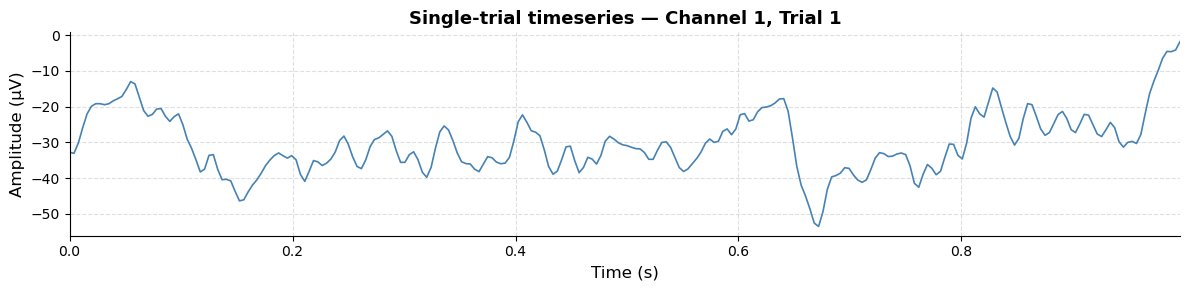

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
# Plot the response of the first channel  of the first trial
ax.plot(t, responses[:, 0, 0], color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Single-trial timeseries — Channel 1, Trial 1', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 1.2

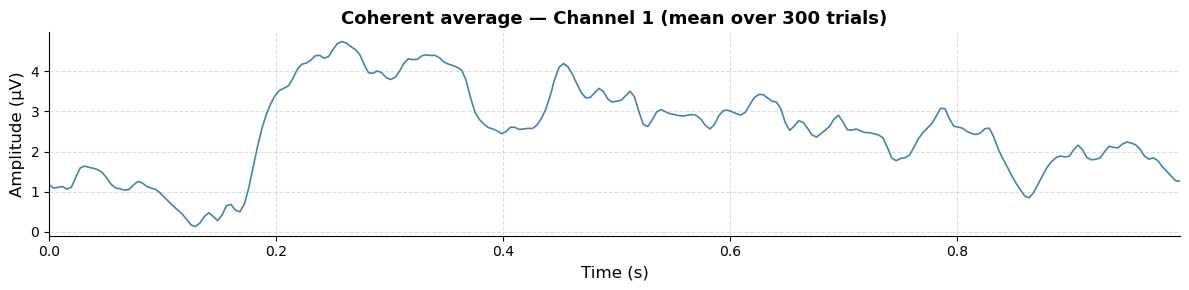

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
# Plot the mean of the responses across trials
ax.plot(t, responses[:, 0, :].mean(axis=1), color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Coherent average — Channel 1 (mean over 300 trials)', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2
## 2.1

In [ ]:
import numpy.fft as fft

def power_spectrum(signal, fs):
    """
    Hamming-windowed, single-sided power spectrum of a 1D signal segment.
    """
    n = len(signal)
    # Hamming windowing
    window = np.hamming(n) * signal
    # Get coefficients & frequencies
    coeffs = fft.rfft(window)
    freqs = fft.rfftfreq(n, d=1/fs)
    # Returns frequencies and single-sided power spectrum
    return freqs, np.abs(coeffs)

In [ ]:
# Coherent average across trials: (256, 10)
avg = responses.mean(axis=2)

# Compute power spectrum per channel
freqs, _ = power_spectrum(avg[:, 0], fs)
power = np.stack([power_spectrum(avg[:, ch], fs)[1] for ch in range(avg.shape[1])], axis=1)

## 2.2 - 2.3

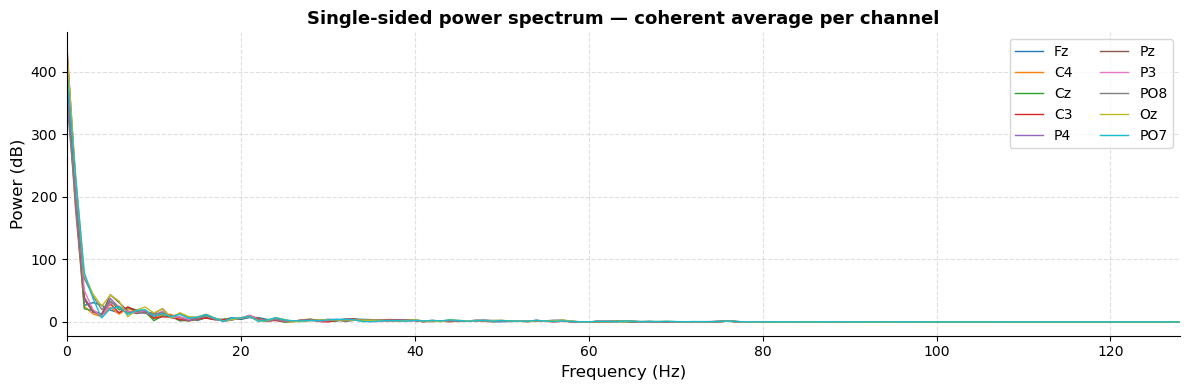

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plot power spectrum for all channels
for ch in range(power.shape[1]):
    ax.plot(freqs, power[:, ch], linewidth=1.0, label=electrodes[ch])

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power (dB)", fontsize=12)
ax.set_title("Single-sided power spectrum — coherent average per channel", fontsize=13, fontweight="bold")
ax.set_xlim(0, freqs[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


# 3
## 3.1 - 3.4

In [ ]:
# Sliding window length and step size
win_size = 32
step_size = 32

# Windows, frequency bins
starts = range(0, avg.shape[0] - win_size + 1, step_size)
freqs_stft, _ = power_spectrum(avg[:win_size, 0], fs)

# Spectrogram for all channels, shape: (n_steps, n_freqs, n_channels)
spectrogram = np.stack([
    np.array([power_spectrum(avg[s:s + win_size, ch], fs)[1] for s in starts])
    for ch in range(avg.shape[1])
], axis=2)

# Time vector, at the midpoints of the windows
t_steps = np.array([s + win_size / 2 for s in starts]) / fs

## 3.5-3.6

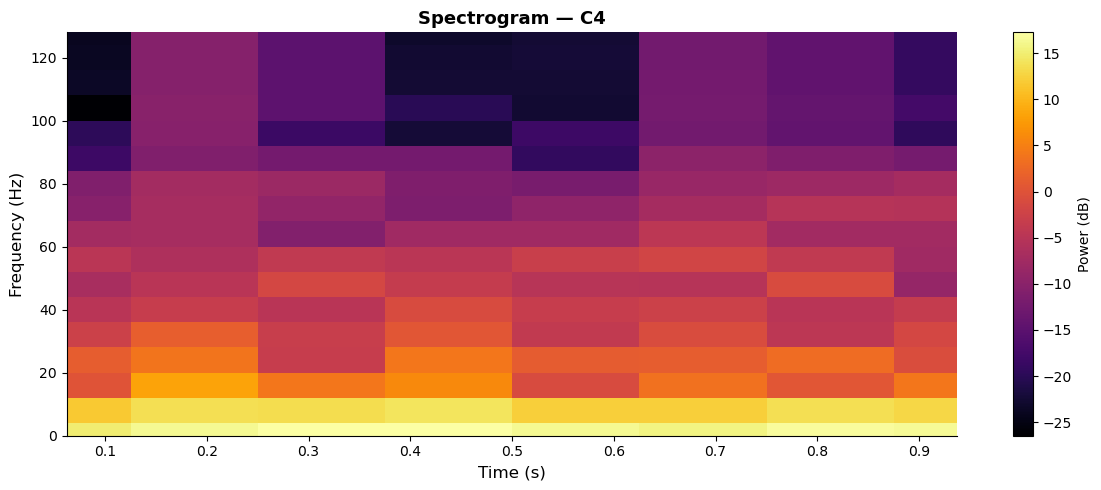

In [ ]:
# Channels: 0=Fz, 1=C4, 2=Cz, 3=C3, 4=P4, 5=Pz, 6=P3, 7=PO8, 8=Oz, 9=PO7
ch = 1

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(t_steps, freqs_stft, 10 * np.log10(spectrogram[:, :, ch]).T,
                   shading="auto", cmap="inferno")
fig.colorbar(im, ax=ax, label="Power (dB)")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Frequency (Hz)", fontsize=12)
ax.set_title(f"Spectrogram — {electrodes[ch]}", fontsize=13, fontweight="bold")
ax.set_xlim(t_steps[0], t_steps[-1])
ax.set_ylim(0, freqs_stft[-1])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 4
## 4.1